# Modelo de Regresión Lineal, para predecir el valor del mercado del proximo mes.
## creat_at: Ronald Barberi (KretoN)

### Importar librerias

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Inicializamos variables globales para el modelo.

In [2]:
path_main = os.getcwd()
dic_args = {
    'path_data_inp': os.path.join(path_main, '..', 'data', 'data_market.xlsx'),
    'path_data_out': os.path.join(path_main, '..', 'data', 'prediccion_mercado.csv'),
    'values_pred': [
        'Leche','Huevos','Arveja','Mantequilla','Panela','Arveja','Azucar','Pasta Seco',
        'Harina de Trigo','Harina de Arepas','Aceite','Condimentos','Jabon en Polvo (Ropa)','Papel Higienico'
    ]
}

### Generamos el DataFrame con el cual realizaremos el modelo

In [3]:
df = pd.read_excel(dic_args['path_data_inp'])
df.head(5)

C:\hdfs\data_science\projects\mdl_rg_lnl_mercado\venv\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,periodo,quincena,item,detalle,unidad,sub_unidades,promocion,peso_kg,peso_g,peso_l,peso_ml,valor_individual,valor_total,vlr_ttl_coalesce
0,202504,1,Arroz,NaN,1,NaN,NaN,10.0,NaN,NaN,NaN,22000.0,NaN,22000
1,202504,1,Leche,NaN,1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,36900.0,36900
2,202504,1,Cafe Instanteneo,NaN,1,NaN,NaN,NaN,85.0,NaN,NaN,13300.0,NaN,13300
3,202504,1,Cafe Tradicional,NaN,1,NaN,NaN,NaN,425.0,NaN,NaN,19400.0,NaN,19400
4,202504,1,Huevos,NaN,3,30.0,NaN,NaN,NaN,NaN,NaN,28800.0,NaN,86400


### Realizamos un Coalesce de la columna y seleccionamos únicamente aquellas que requerimos para el modelo.

In [4]:
df['col_val'] = df['valor_individual'].combine_first(df['valor_total'])

df = df[['item','col_val']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   item     124 non-null    object 
 1   col_val  124 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.1+ KB


### Cambiamos el tipo de dato de la variable

In [5]:
df['item'] = df['item'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   item     124 non-null    category
 1   col_val  124 non-null    float64 
dtypes: category(1), float64(1)
memory usage: 3.7 KB


### Generamos graficas para ver el impacto de los Items

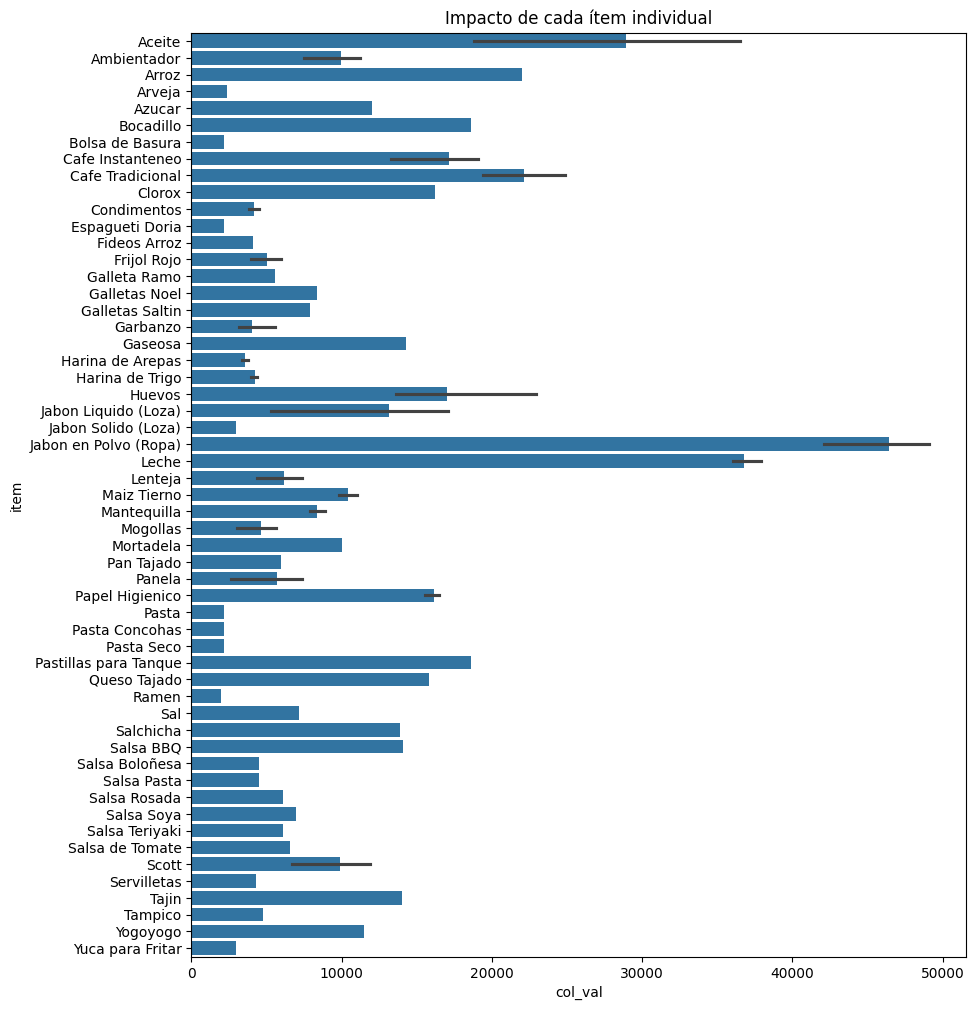

In [6]:
plt.figure(figsize=(10,12))
sns.barplot(
    data=df,
    y='item',
    x='col_val',
)
plt.title('Impacto de cada ítem individual')
plt.show()

### Establecemos el proceso de Codificación de las varaibles cualitativas

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['item']),
    ],
    remainder='passthrough'
)

### Declaramos variable predictoria y variable objetivo

In [8]:
X = df[['item']]
Y = df['col_val']

### Realizamos la división de la data en testeo y prueba.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42,
    stratify=None
)

### Construcción del flujo de datos y su implementación de modelos.

In [10]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

### Entrenamiento de modelo.

In [11]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Generamos DataFrame para almacenar los datos predictorios

In [12]:
df_pred = pd.DataFrame({'item': dic_args['values_pred']})

### Realizamos la predicción de nueva información.

In [13]:
df_pred['prediccion'] = model.predict(df_pred)
print(df_pred)

                     item    prediccion
0                   Leche  36783.333333
1                  Huevos  14100.000000
2                  Arveja   2400.000000
3             Mantequilla   8500.000000
4                  Panela   5678.000000
5                  Arveja   2400.000000
6                  Azucar  12000.000000
7              Pasta Seco   2200.000000
8         Harina de Trigo   4200.000000
9        Harina de Arepas   3600.000000
10                 Aceite  34150.000000
11            Condimentos   4175.000000
12  Jabon en Polvo (Ropa)  49500.000000
13        Papel Higienico  16500.000000


### Extraemos el intercepto y coeficiente y lo alamcenamos en un DataFrame

In [14]:
# Extraer el modelo lineal interno del pipeline
reg = model.named_steps['classifier']

# Obtener los nombres de las columnas generadas por el preprocesador
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Crear el DataFrame con los coeficientes y el intercepto
df_coef = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': reg.coef_.ravel()
})

df_coef['intercepto'] = reg.intercept_

### Consolidamos la información en un solo DF para la validación de la predicción.

In [15]:
df_pred = df_pred.merge(
    df_coef.assign(item=df_coef['variable'].str.replace('cat__item_', '', regex=False)),
    on='item',
    how='left'
)

df_pred = df_pred.merge(
    df,
    on='item',
    how='left'
)

df_pred.groupby('item', as_index=False).first()

,item,prediccion,variable,coeficiente,intercepto,col_val
0,Aceite,34150.000000,cat__item_Aceite,23821.812500,10328.1875,29400.0
1,Arveja,2400.000000,cat__item_Arveja,-7928.187500,10328.1875,2400.0
2,Azucar,12000.000000,cat__item_Azucar,1671.812500,10328.1875,12000.0
3,Condimentos,4175.000000,cat__item_Condimentos,-6153.187500,10328.1875,3850.0
4,Harina de Arepas,3600.000000,cat__item_Harina de Arepas,-6728.187500,10328.1875,3400.0
5,Harina de Trigo,4200.000000,cat__item_Harina de Trigo,-6128.187500,10328.1875,4200.0
6,Huevos,14100.000000,cat__item_Huevos,3771.812500,10328.1875,28800.0
7,Jabon en Polvo (Ropa),49500.000000,cat__item_Jabon en Polvo (Ropa),39171.812500,10328.1875,37800.0
8,Leche,36783.333333,cat__item_Leche,26455.145833,10328.1875,36900.0
9,Mantequilla,8500.000000,cat__item_Mantequilla,-1828.187500,10328.1875,7800.0


### Generamos grafico para ver el impacto de cada ítem.

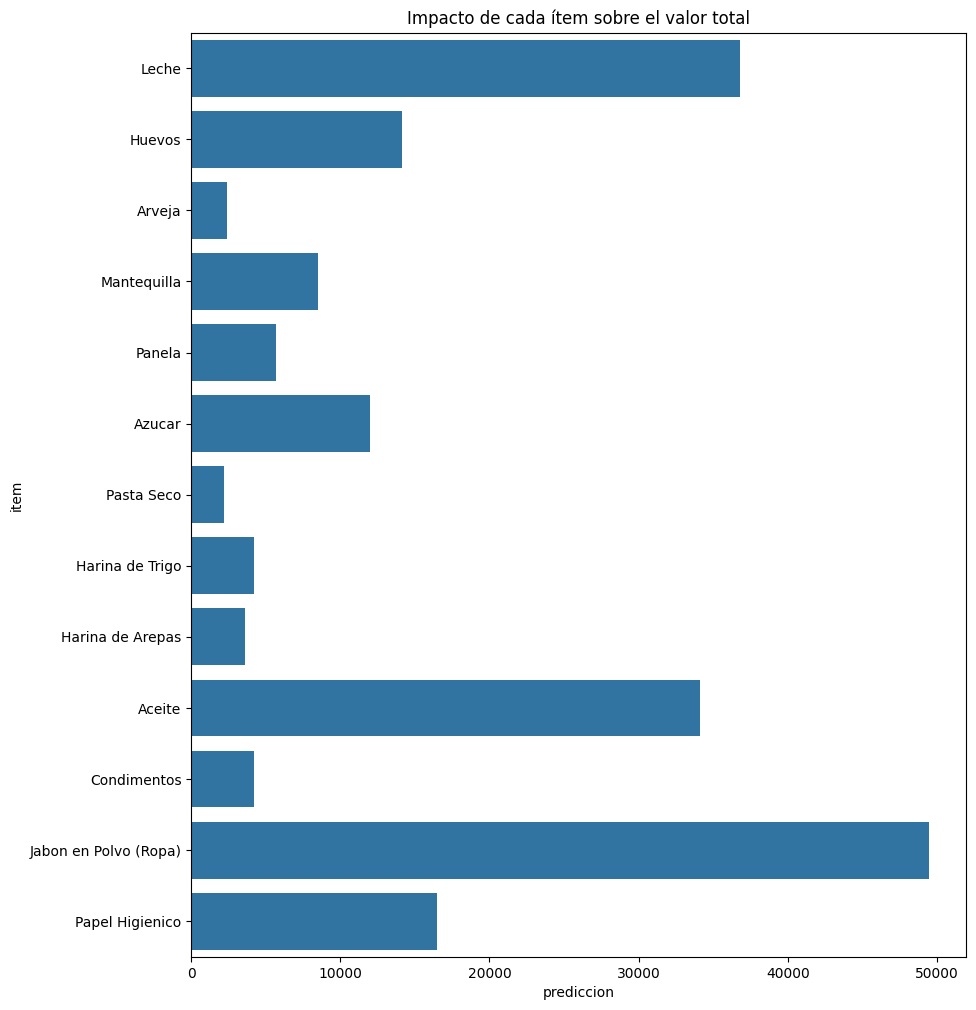

In [16]:
plt.figure(figsize=(10,12))
sns.barplot(
    data=df_pred,
    y='item',
    x='prediccion',
)
plt.title('Impacto de cada ítem sobre el valor total')
plt.show()

### Evaluamoos el Error promedio típico del modelo.

In [17]:
RMSE = mean_squared_error(
    y_true=df_pred['col_val'],
    y_pred=df_pred['prediccion']
)**(1/2)

RMSE = round(RMSE, 3)
RMSE

4150.482

### Generamos grafica de dispersión para validar el modelo y su cercania a los puntos.

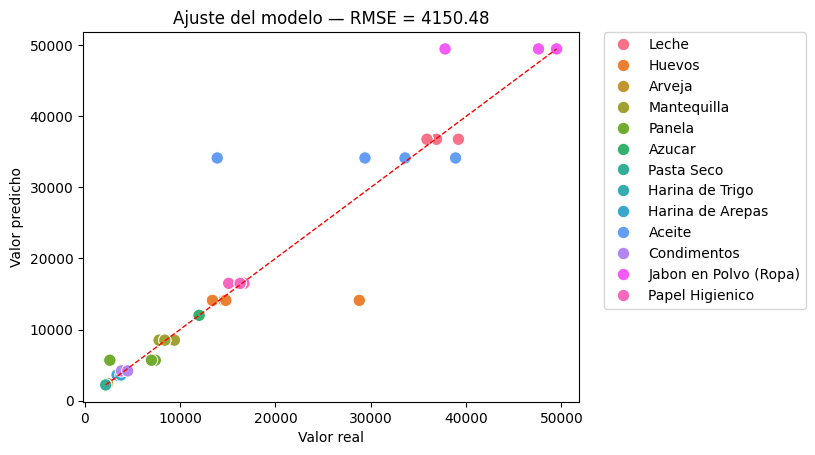

In [18]:
sns.scatterplot(
    data=df_pred,
    x='col_val',
    y='prediccion',
    hue='item',
    s=80
)

# Línea de identidad
min_val = min(df_pred['col_val'].min(), df_pred['prediccion'].min())
max_val = max(df_pred['col_val'].max(), df_pred['prediccion'].max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title(f'Ajuste del modelo — RMSE = {RMSE:.2f}')
plt.show()

### Construimos el DataFrame y exportamos los resultados del modelo.

In [19]:
df_pred = df_pred[['item', 'intercepto', 'coeficiente', 'prediccion']]
df_pred['prediccion'] = round(df_pred['prediccion'], 3)
df_pred = df_pred.drop_duplicates(subset='item', keep='first')
df_pred

try:
    df_pred.to_csv(dic_args['path_data_out'], sep=',', index=False)
    print('[OK] predicciones exportadas')
except Exception as err:
    print(f'[ERROR] error al exportar las predicciones: {err}')

[OK] predicciones exportadas


### Imprimir los resultados del modelo en consola.

In [20]:
print('Valor total del mercado', df_pred['prediccion'].sum())
df_pred

Valor total del mercado 193786.33299999998


,item,intercepto,coeficiente,prediccion
0,Leche,10328.1875,26455.145833,36783.333
6,Huevos,10328.1875,3771.812500,14100.000
11,Arveja,10328.1875,-7928.187500,2400.000
12,Mantequilla,10328.1875,-1828.187500,8500.000
17,Panela,10328.1875,-4650.187500,5678.000
21,Azucar,10328.1875,1671.812500,12000.000
24,Pasta Seco,10328.1875,-8128.187500,2200.000
26,Harina de Trigo,10328.1875,-6128.187500,4200.000
31,Harina de Arepas,10328.1875,-6728.187500,3600.000
33,Aceite,10328.1875,23821.812500,34150.000
